# Infraslow fluctuation of sigma power (ISFS) — YASA demo

Reproduces **Figure 1: Overview of analyses assessing the infraslow fluctuation of
sigma power** using this repo's `infraslow` package with the YASA spindle detector.

- **A** — hypnogram with NREM-2 bouts ≥ 200 s that contain ≥1 detected spindle highlighted (green), and the
  raw EEG time series with detected spindles marked in blue.
- **B** — the sigma-power (10–16 Hz) time course of the same window, spindles as blue dots.
- **C-i** — relative spectral power of the sigma-power course (baseline-corrected over
  0.06–0.1 Hz), with a Gaussian fit giving peak frequency, bandwidth and area under the curve.
- **C-ii** — the sigma-power course band-pass filtered to the infraslow band, standardized,
  and divided into eight phase bins (1–4 negative half wave, 5–8 positive half wave).

> The package derives the sigma-power course from the **Hilbert** analytic power of the
> 10–16 Hz band — a practical stand-in for the paper's wavelet-derived sigma power.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, ConnectionPatch
from scipy.optimize import curve_fit
from scipy.signal import hilbert, find_peaks

from infraslow import BioserenityPSGLoader
from infraslow.processing.detection import (
    spindles_detect,
    _extract_epoch_stages,
    _stages_to_int,
    DEFAULT_STAGE_MAP,
    DEFAULT_EPOCH_SEC,
)
from infraslow.processing.infraslow import (
    sigma_power_envelope,
    infraslow_spectrum,
    DEFAULT_SF_ENV,
)
from infraslow.processing.signal import ButterFilter
from infraslow.viz import plot_hypnogram

plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE, BLUE = '#5b2a86', '#c9b3e6', 'tab:blue'
_trapz = getattr(np, 'trapezoid', np.trapz)   # NumPy 2.0 renamed trapz

## Load one subject and detect spindles

In [2]:
SUBJECT = '318679'
CHANNEL = 'C3'
SF = 200
SIGMA_BAND = (10.0, 16.0)      # Fig. 1B: sigma power = |power| averaged over 10-16 Hz
INFRASLOW_BAND = (0.01, 0.1)   # ISFS search band()
BASELINE_BAND = (0.06, 0.1)    # Fig. 1C-i: baseline-correction band (red line)
MIN_BOUT_SEC = 200             # Fig. 1A: consecutive artifact-free N2 bouts >= 200 s
WINDOW_SEC = 100
EPOCH_SEC = DEFAULT_EPOCH_SEC  # 30 s scored epochs
ISFS_PERIOD = (25.0, 100.0)    # Fig. 1C-ii: infraslow time scale (s)

loader = BioserenityPSGLoader(
    subject_id=SUBJECT, sf=SF, requested_channels=[CHANNEL]
).load()
data = np.asarray(loader.get_channel(CHANNEL), dtype=float)
sf = float(loader.sf)
duration_sec = len(data) / sf
print(f'{SUBJECT} {CHANNEL}: {len(data)} samples @ {sf:g} Hz = {duration_sec/60:.1f} min')

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f1dcc12caf0> 

318679 C3: 5502000 samples @ 200 Hz = 458.5 min


  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

In [3]:
def nrem2_bouts(loader, *, epoch_sec=EPOCH_SEC, min_dur=MIN_BOUT_SEC, stage_code=2):
    """(start, stop) times (s) of runs of consecutive N2 epochs lasting >= min_dur."""
    codes = _stages_to_int(
        _extract_epoch_stages(loader.annotations, stage_column='stage'),
        DEFAULT_STAGE_MAP,
    )
    bouts, i, n = [], 0, len(codes)
    while i < n:
        if codes[i] == stage_code:
            j = i
            while j < n and codes[j] == stage_code:
                j += 1
            if (j - i) * epoch_sec >= min_dur:
                bouts.append((i * epoch_sec, j * epoch_sec))
            i = j
        else:
            i += 1
    return bouts

bouts_all = nrem2_bouts(loader)
print(f'{len(bouts_all)} NREM2 bout(s) >= {MIN_BOUT_SEC:g}s (before spindle filter)')

# Fig. 1A/B: sleep spindles on C3, restricted to N2, detected with YASA.
sp = spindles_detect(loader, ch_names=CHANNEL, include=(2,))
peaks = sp.summary()['Peak'].to_numpy()
starts = sp.summary()['Start'].to_numpy()
ends = sp.summary()['End'].to_numpy()
print(f'{len(peaks)} spindles detected')

# Infraslow uses ONLY N2 bouts that contain >= 1 detected spindle
# (spindle-free bouts are dropped).
bouts = [(a, b) for a, b in bouts_all if np.any((peaks >= a) & (peaks < b))]
total_min = sum(b - a for a, b in bouts) / 60
print(f'{len(bouts)}/{len(bouts_all)} bout(s) contain >= 1 spindle; total {total_min:.1f} min')

24 NREM2 bout(s) >= 200s (before spindle filter)


09-Jul-26 14:20:38 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


308 spindles detected
23/24 bout(s) contain >= 1 spindle; total 191.0 min


## Sigma-power time course (Fig. 1B input)

Hilbert analytic power of the 10–16 Hz band, averaged into 1 s bins. We keep both the
**dB** course (used for the spectrum, matching the reference `get_iso`) and a **linear**
course (used for the time-course displays).

In [4]:
t_env, sigma_db = sigma_power_envelope(
    data, sf, sigma_band=SIGMA_BAND, sf_env=DEFAULT_SF_ENV, smooth_sec=1.0, to_db=True
)
_, sigma_lin = sigma_power_envelope(
    data, sf, sigma_band=SIGMA_BAND, sf_env=DEFAULT_SF_ENV, smooth_sec=1.0, to_db=False
)

def env_at(times, t=t_env, y=sigma_lin):
    """Sigma-power value interpolated at spindle times (for the blue dots)."""
    return np.interp(times, t, y)

# --- Select which N2 bout to visualize (drives Fig 1A, 1B and 1C-ii) ---
# Change BOUT_IDX to any value in range(len(bouts)) to move the window
# dynamically; Fig 1A (zoom + EEG), Fig 1B and Fig 1C-ii all follow this bout.
WIN_SEC = 200
BOUT_IDX = 18
BOUT_IDX = max(0, min(BOUT_IDX, len(bouts) - 1))   # clamp to a valid bout
bout0 = bouts[BOUT_IDX]
z0 = bout0[0]
z1 = min(bout0[0] + WIN_SEC, bout0[1])
WIN = (z0, z1)
print(f'Selected bout #{BOUT_IDX} of {len(bouts)}: {bout0[0]:.0f}-{bout0[1]:.0f}s '
      f'({bout0[1] - bout0[0]:.0f}s); Fig A/B window {z0:.0f}-{z1:.0f}s ({z1 - z0:.0f}s)')

Selected bout #18 of 23: 19950-20460s (510s); Fig A/B window 19950-20150s (200s)


## Figure 1A — hypnogram + sigma-filtered EEG with spindles

Top: hypnogram, N2 highlighted, with >= 200 s spindle-containing N2 bouts shaded green. A **420 s window**
(red box, same window as Fig B) marks the slice expanded below. Bottom: the C3 EEG
**band-pass filtered to the sigma band (10-16 Hz)** in grey, with each detected spindle's
Start-End segment in blue. Red dashed connectors link the marked window to the trace.

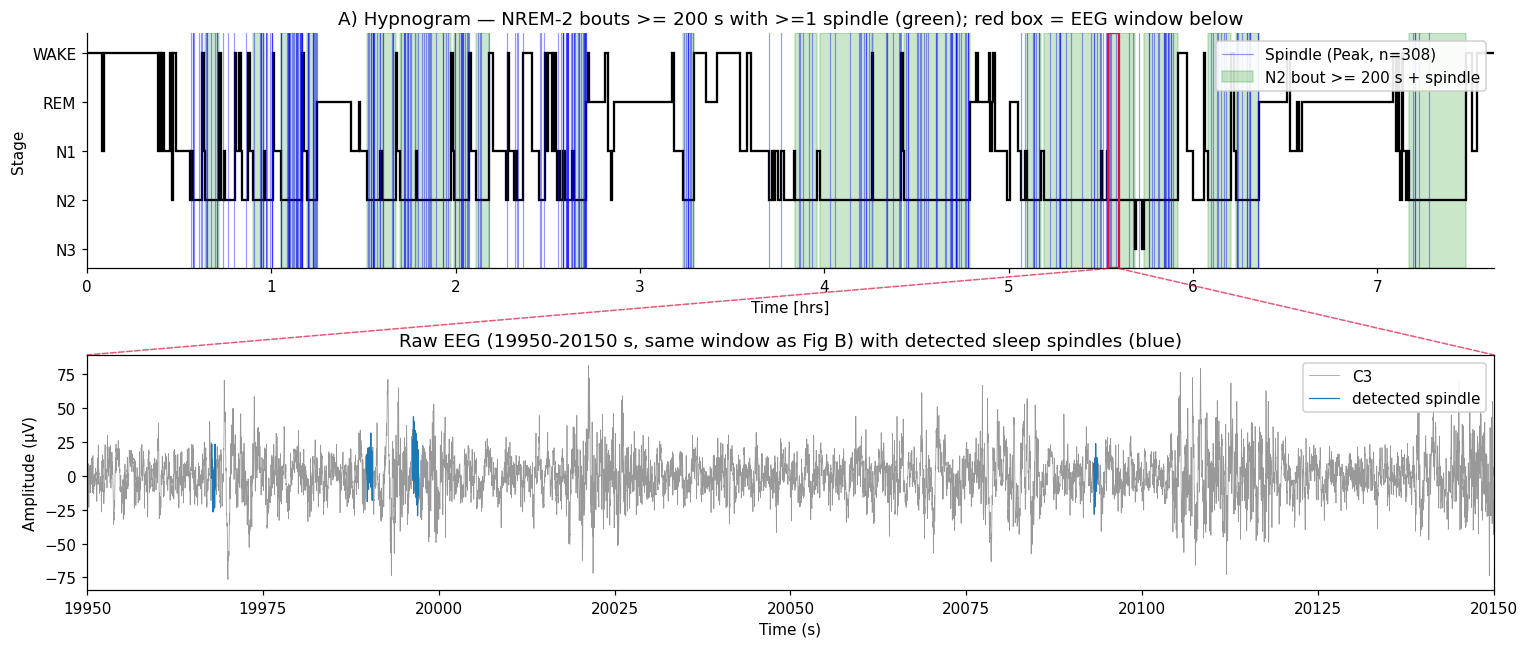

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
w0, w1 = WIN                                     # same 420 s window as Fig B
# eeg_sigma = ButterFilter(sf, [1, 30], mode='band', order=6)(data)  # 10-16 Hz


# --- Top: hypnogram, N2 bouts >= 280 s shaded green (x-axis is in hours) ---
plot_hypnogram(loader, spindles=sp, highlight=None, ax=axes[0], mark_color='blue')
for k, (a, b) in enumerate(bouts):
    axes[0].axvspan(a / 3600, b / 3600, color='tab:green', alpha=0.25, zorder=0,
                    label=f'N2 bout >= {MIN_BOUT_SEC} s + spindle' if k == 0 else None)

# --- Mark the 420 s window (WIN, shared with Fig B) on the hypnogram ---
axes[0].axvspan(w0 / 3600, w1 / 3600, facecolor='none', edgecolor='crimson',
                lw=1.5, zorder=6)
# axes[0].annotate('zoom', xy=((w0 + w1) / 2 / 3600, axes[0].get_ylim()[1]),
#                  xytext=(0, 4), textcoords='offset points', ha='center',
#                  color='crimson', fontsize=9, fontweight='bold')
axes[0].set_title(f'A) Hypnogram — NREM-2 bouts >= {MIN_BOUT_SEC} s with >=1 spindle (green); red box = EEG window below')
axes[0].legend(loc='upper right', frameon=True, framealpha=0.9)

# --- Bottom: sigma-filtered EEG over the WIN window (grey) with spindles in blue ---
t = np.arange(len(data)) / sf
m = (t >= w0) & (t <= w1)
axes[1].plot(t[m], data[m], color='0.6', lw=0.5, label='C3')
in_win = (starts < w1) & (ends > w0)
first = True
for s0, e0 in zip(starts[in_win], ends[in_win]):
    seg = (t >= s0) & (t <= e0)
    axes[1].plot(t[seg], data[seg], color=BLUE, lw=0.8,
                 label='detected spindle' if first else None)
    first = False
axes[1].set(xlim=(w0, w1), xlabel='Time (s)', ylabel='Amplitude (µV)',
            title=f'Raw EEG ({w0:.0f}-{w1:.0f} s, same window as Fig B) '
                  'with detected sleep spindles (blue)')
axes[1].legend(loc='upper right', frameon=True, framealpha=0.9)

# --- Red dashed connectors from the hypnogram window down to the EEG axes ---
y_hyp = axes[0].get_ylim()[0]
y_eeg = axes[1].get_ylim()[1]
for x in (w0, w1):
    fig.add_artist(ConnectionPatch(
        xyA=(x / 3600, y_hyp), coordsA=axes[0].transData,
        xyB=(x, y_eeg), coordsB=axes[1].transData,
        color='crimson', lw=1.0, ls='--', alpha=0.7))

fig.tight_layout()

## Figure 1B — sigma-power time course

The sigma-power (10-16 Hz) course over the **whole first bout** (the same bout Fig A's zoom
is taken from) in grey, with each detected spindle marked as a blue dot at its peak time.
The red band marks the 30 s window expanded in Fig A.

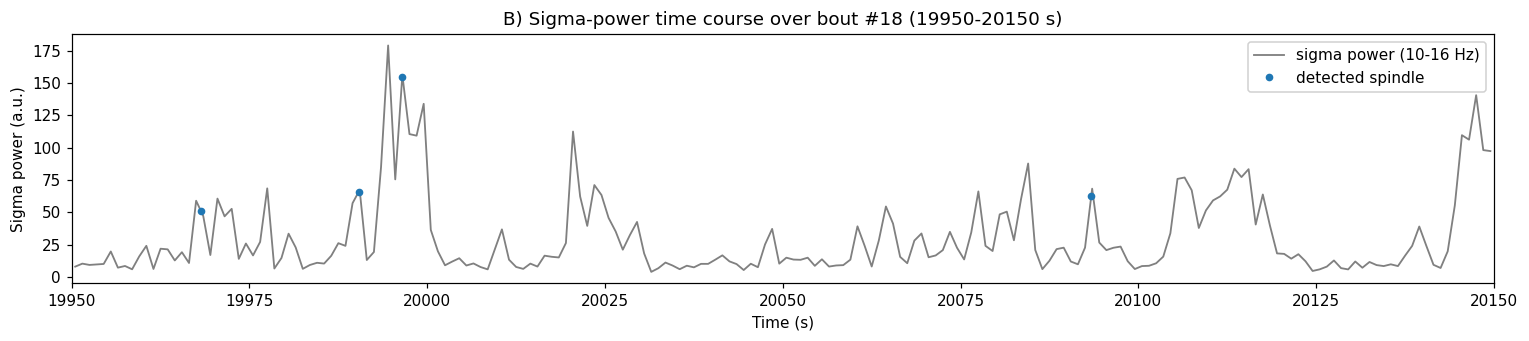

In [6]:
fig, ax = plt.subplots(figsize=(14, 3.2))
me = (t_env >= WIN[0]) & (t_env <= WIN[1])
ax.plot(t_env[me], sigma_lin[me], color='0.5', lw=1.2, label='sigma power (10-16 Hz)')
pk = peaks[(peaks >= WIN[0]) & (peaks <= WIN[1])]
ax.plot(pk, env_at(pk), 'o', color=BLUE, ms=4, label='detected spindle')
ax.set(xlim=WIN, xlabel='Time (s)', ylabel='Sigma power (a.u.)',
       title=f'B) Sigma-power time course over bout #{BOUT_IDX} ({WIN[0]:.0f}-{WIN[1]:.0f} s)')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
fig.tight_layout()

## Figure 1C-i — relative spectral power, baseline correction & Gaussian fit

The relative spectral power is the mean Welch spectrum of the sigma-power course across all
bouts, normalized to unit in-band area. Baseline correction subtracts the mean power over
0.06–0.1 Hz (red line). A Gaussian is fit to the corrected spectrum; if its peak exceeds the
threshold (1.5 × the noise SD in the baseline band) the ISFS is detected and its peak
frequency, bandwidth (**2·SD**, i.e. ±1 SD around the peak) and area under the curve
(power within that **same ±1 SD range**) are estimated.

In [7]:
# One Welch spectrum per bout on a common frequency grid, then averaged.
segs = [sigma_db[(t_env >= a) & (t_env < b)] for a, b in bouts]
segs = [s for s in segs if len(s) >= 64]
# wsec = min(len(s) for s in segs)                       # identical freq grid for all bouts
specs = [infraslow_spectrum(s, DEFAULT_SF_ENV, band=INFRASLOW_BAND, window_sec=WINDOW_SEC)
         for s in segs]
freqs = specs[0].freqs
mean_psd = np.mean([sp_.psd for sp_ in specs], axis=0)

# Relative spectral power (unit in-band area) and baseline correction over 0.06-0.1 Hz.
band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])
rel = mean_psd / _trapz(mean_psd[band_m], freqs[band_m])
base_m = (freqs >= BASELINE_BAND[0]) & (freqs <= BASELINE_BAND[1])
baseline = rel[base_m].mean()
corrected = rel - baseline

# Gaussian fit over the ISFS candidate range (below the baseline band).
def gaussian(f, amp, mu, sd):
    return amp * np.exp(-0.5 * ((f - mu) / sd) ** 2)

fit_m = (freqs >= INFRASLOW_BAND[0]) & (freqs < BASELINE_BAND[0])
ff, yy = freqs[fit_m], corrected[fit_m]
p0 = [max(yy.max(), 1e-9), ff[np.argmax(yy)], 0.01]
popt, _ = curve_fit(gaussian, ff, yy, p0=p0,
                    bounds=([0, INFRASLOW_BAND[0], 1e-3], [np.inf, BASELINE_BAND[0], 0.05]),
                    maxfev=10000)
amp, mu, sd = popt

# ISFS parameters. Bandwidth and AUC share the SAME range: peak +/- 1 SD.
lo, hi = mu - sd, mu + sd            # +/-1 SD around the peak frequency
bandwidth = hi - lo                  # = 2*sd (variability in period of the ISFS)
f_auc = np.linspace(lo, hi, 400)     # fine grid: coarse PSD bins undercount the area
auc = float(_trapz(gaussian(f_auc, *popt), f_auc))   # total power within +/-1 SD

# Detection: peak power (Gaussian amplitude) must surpass the threshold.
threshold = 1.5 * corrected[base_m].std()   # 1.5x SD of the baseline-band (noise) spectrum
detected = amp > threshold
print(f'ISFS detected: {detected} | peak {mu:.4f} Hz (~{1/mu:.0f} s) | '
      f'bandwidth {bandwidth:.4f} Hz (+/-1 SD: {lo:.4f}-{hi:.4f}) | AUC {auc:.3g}')

ISFS detected: True | peak 0.0248 Hz (~40 s) | bandwidth 0.0307 Hz (+/-1 SD: 0.0094-0.0401) | AUC 0.461


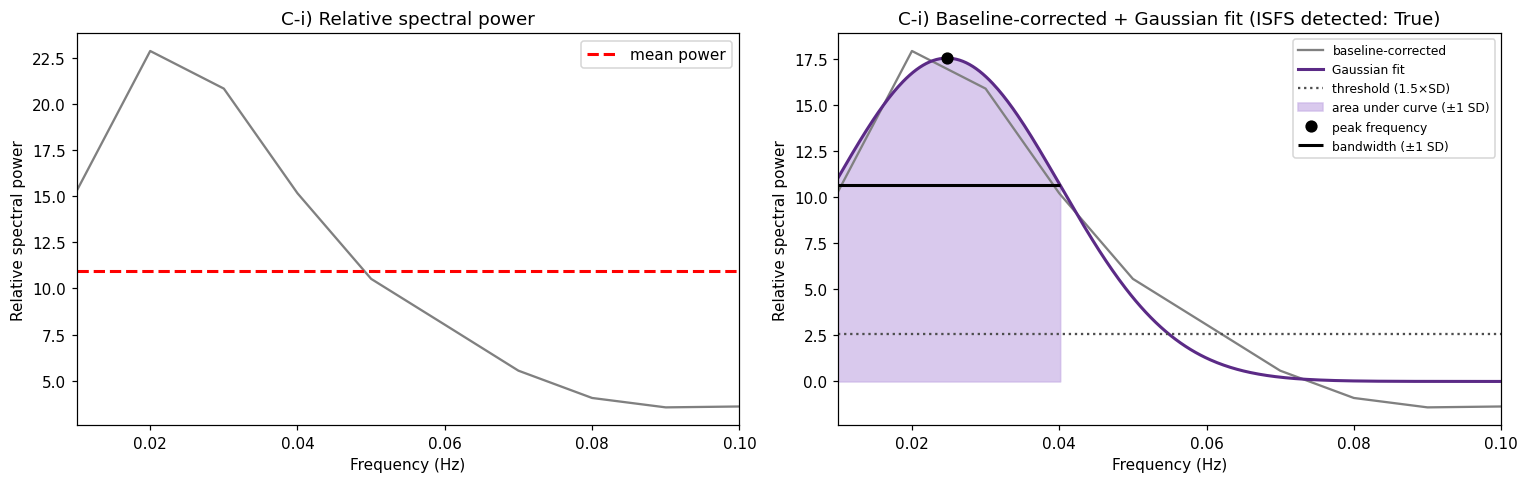

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5))

# --- Left: relative spectral power with the baseline band marked in red ---
axL.plot(freqs[band_m], rel[band_m], color='0.5', lw=1.5)
mean_power = rel[band_m].mean()
axL.axhline(mean_power, color='red', lw=2, ls='--', label='mean power')
axL.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
        title='C-i) Relative spectral power')
axL.legend(frameon=True)

# --- Right: baseline-corrected spectrum + Gaussian fit + ISFS parameters ---
axR.plot(freqs[band_m], corrected[band_m], color='0.5', lw=1.5, label='baseline-corrected')
fg = np.linspace(*INFRASLOW_BAND, 400)
axR.plot(fg, gaussian(fg, *popt), color=PURPLE, lw=2, label='Gaussian fit')
axR.axhline(threshold, ls=':', color='0.3', label='threshold (1.5×SD)')
axR.fill_between(f_auc, gaussian(f_auc, *popt), color=LPURPLE, alpha=0.7,
                 label='area under curve (±1 SD)')
axR.plot([mu], [gaussian(mu, *popt)], 'o', color='k', ms=7, zorder=5, label='peak frequency')
axR.hlines(gaussian(lo, *popt), lo, hi, color='k', lw=2, label='bandwidth (±1 SD)')
axR.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
        title=f'C-i) Baseline-corrected + Gaussian fit (ISFS detected: {detected})')
axR.legend(frameon=True, fontsize=8)
fig.tight_layout()

## Figure 1C-ii — filtered sigma power, standardization & phase bins

Top: the sigma-power course (grey) with spindles (blue dots) and the infraslow-band filtered
course (black). Bottom: the filtered course standardized (z-scored), with peaks, troughs and
zero-crossings marked, and one valid ISFS cycle (period 25-100 s, containing both a peak and
a trough) split into eight phase bins: 1-4 span the negative half wave, 5-8 the positive half
wave. The x-axis shows a `CII_WINDOW_SEC`-long window centred on that cycle (set `CII_BOUT` to plot
a different bout, `CII_WINDOW_SEC` to lengthen the view). Bins 1-4 and 5-8 span the negative
and positive half-waves, whose durations differ, so the two bin groups are not equal width.

In [9]:
# --- Fig C-ii tracks the same bout selected above (BOUT_IDX) ---
CII_BOUT = BOUT_IDX          # index into `bouts`; follows Fig 1A/1B selection
CII_WINDOW_SEC = WIN_SEC     # length (s) of the C-ii view; increase to make it longer

# --- Filter the chosen bout's sigma-power course into the infraslow band ---
a, b = bouts[CII_BOUT]
m0 = (t_env >= a) & (t_env < b)
tt = t_env[m0] - a                       # bout-relative time (s), 1 Hz sampling
raw = sigma_db[m0]
filt = ButterFilter(DEFAULT_SF_ENV, list(INFRASLOW_BAND), mode='band', order=2)(raw)
std = (filt - filt.mean()) / filt.std()  # standardized (z-scored) filtered course

# --- Peaks, troughs, and zero-crossings of the standardized course ---
pk_i, _ = find_peaks(std)
tr_i, _ = find_peaks(-std)
zc_i = np.where(np.diff(np.signbit(std)))[0]                 # index just before each crossing
desc = zc_i[std[zc_i] > 0]                                   # descending (+ -> -) crossings
asc = zc_i[std[zc_i] < 0]                                    # ascending  (- -> +) crossings

def first_valid_cycle():
    """First descending->descending cycle with one trough + one peak, period 25-100 s."""
    for k in range(len(desc) - 1):
        c0, c1 = desc[k], desc[k + 1]
        if not ISFS_PERIOD[0] <= (tt[c1] - tt[c0]) <= ISFS_PERIOD[1]:
            continue
        mid = asc[(asc > c0) & (asc < c1)]
        tr = tr_i[(tr_i > c0) & (tr_i < c1)]
        pk = pk_i[(pk_i > c0) & (pk_i < c1)]
        if len(mid) and len(tr) and len(pk):
            return c0, mid[0], c1     # neg half: c0->mid, pos half: mid->c1
    return None

cycle = first_valid_cycle()
print('valid ISFS cycle found' if cycle else 'no fully-estimable cycle (Not ISFS)')

valid ISFS cycle found


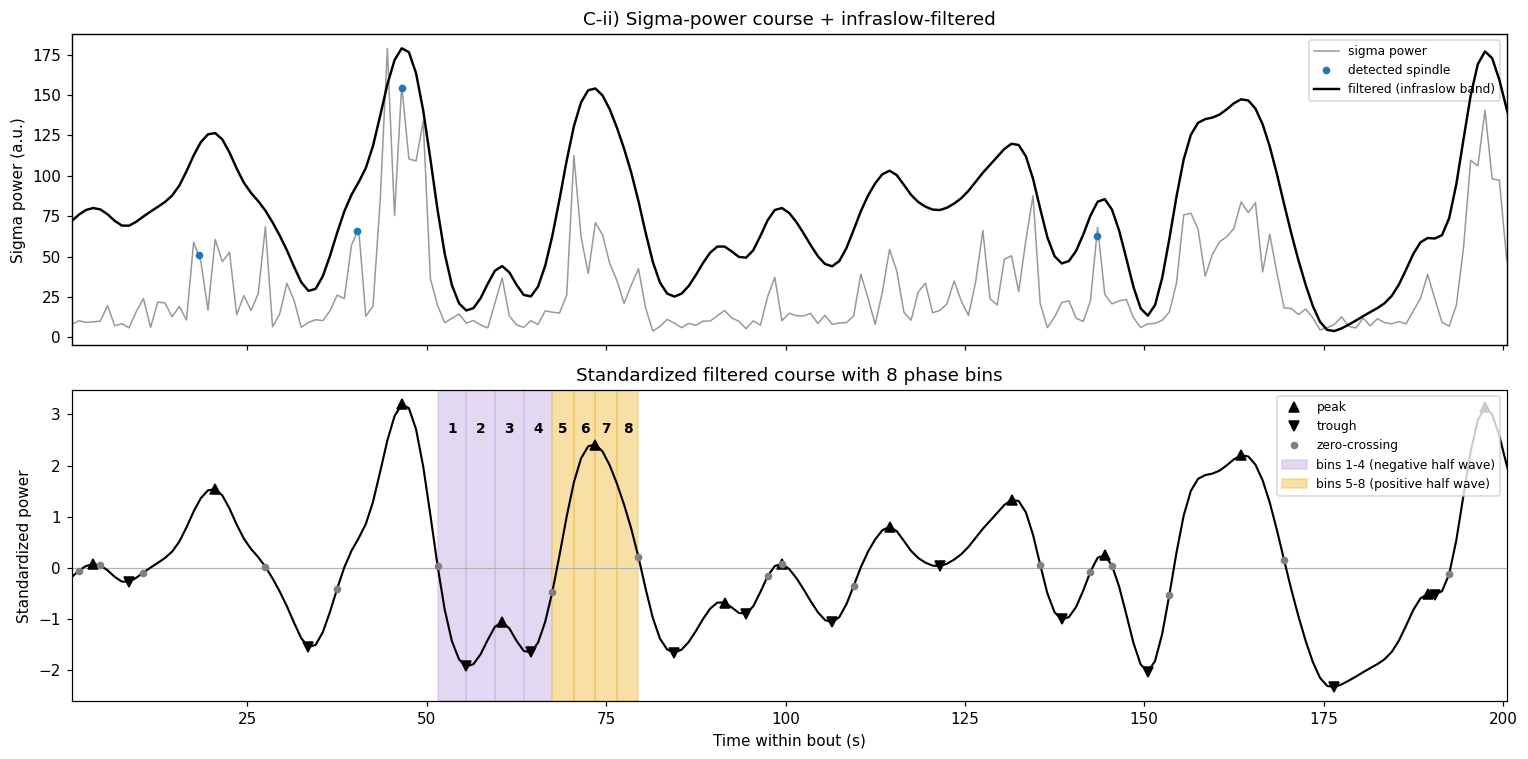

In [10]:
fig, (axT, axB) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- Top: sigma-power course (grey), spindles (blue dots), filtered course (black) ---
axT.plot(tt, sigma_lin[m0], color='0.6', lw=1.0, label='sigma power')
pk_t = peaks[(peaks >= a) & (peaks < b)]
axT.plot(pk_t - a, env_at(pk_t), 'o', color=BLUE, ms=4, label='detected spindle')
axT2 = axT.twinx()
axT2.plot(tt, filt, color='k', lw=1.6, label='filtered (infraslow band)')
axT2.set_yticks([])
axT.set(ylabel='Sigma power (a.u.)', title='C-ii) Sigma-power course + infraslow-filtered')
l1, la1 = axT.get_legend_handles_labels()
l2, la2 = axT2.get_legend_handles_labels()
axT.legend(l1 + l2, la1 + la2, loc='upper right', frameon=True, fontsize=8)

# --- Bottom: standardized course, peaks/troughs/zero-crossings, 8 phase bins ---
axB.axhline(0, color='0.7', lw=0.8)
axB.plot(tt, std, color='k', lw=1.4)
axB.plot(tt[pk_i], std[pk_i], '^', color='k', ms=7, label='peak')
axB.plot(tt[tr_i], std[tr_i], 'v', color='k', ms=7, label='trough')
axB.plot(tt[zc_i], std[zc_i], 'o', color='0.5', ms=4, label='zero-crossing')

if cycle:
    c0, mid, c1 = cycle
    neg = np.linspace(tt[c0], tt[mid], 5)    # 4 bins across the negative half wave
    pos = np.linspace(tt[mid], tt[c1], 5)    # 4 bins across the positive half wave
    edges = np.concatenate([neg, pos[1:]])
    for i in range(8):
        col = LPURPLE if i < 4 else '#f2c14e'
        axB.axvspan(edges[i], edges[i + 1], color=col, alpha=0.5, zorder=0)
        axB.text((edges[i] + edges[i + 1]) / 2, axB.get_ylim()[1] * 0.82, str(i + 1),
                 ha='center', va='top', fontsize=9, fontweight='bold')
    axB.legend(handles=axB.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, alpha=0.5, label='bins 1-4 (negative half wave)'),
        Patch(color='#f2c14e', alpha=0.5, label='bins 5-8 (positive half wave)')],
        loc='upper right', frameon=True, fontsize=8)
    # Show a CII_WINDOW_SEC-long window centred on the highlighted cycle.
    centre = (tt[c0] + tt[c1]) / 2
    x0 = max(float(tt[0]), centre - CII_WINDOW_SEC / 2)
    xlim = (x0, min(float(tt[-1]), x0 + CII_WINDOW_SEC))
else:
    axB.legend(loc='upper right', frameon=True, fontsize=8)
    xlim = (float(tt[0]), min(float(tt[-1]), CII_WINDOW_SEC))

axB.set(xlim=xlim, xlabel='Time within bout (s)',
        ylabel='Standardized power', title='Standardized filtered course with 8 phase bins')
fig.tight_layout()